# Model Comparison for Cryptocurrency Price Prediction

This notebook compares all the trained models for cryptocurrency price prediction:

1. Load all trained models
2. Compare their performance metrics
3. Visualize performance comparisons
4. Select the best model based on desired criteria

We'll evaluate the models based on multiple metrics including MAE, RMSE, R², MAPE, and Directional Accuracy to provide a comprehensive comparison.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import glob
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import explained_variance_score, median_absolute_error

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')

In [2]:
# Load the train-test split data for evaluation
with open('../models/train_test_split.pkl', 'rb') as f:
    data = pickle.load(f)
    
X_test = data['X_test']
y_test = data['y_test']
dates_test = data['dates_test']

print(f"Loaded test data with {len(X_test)} samples")

Loaded test data with 164918 samples


In [6]:
# Function to evaluate regression models
def evaluate_regression_model(y_true, y_pred):
    """
    Calculate common regression metrics for model evaluation.
    
    Parameters:
        y_true: True target values
        y_pred: Predicted target values
        
    Returns:
        Dictionary of evaluation metrics
    """
    # Ensure arrays have the same length
    if len(y_true) != len(y_pred):
        min_length = min(len(y_true), len(y_pred))
        y_true = y_true[:min_length]
        y_pred = y_pred[:min_length]
        print(f"Warning: Arrays had different lengths. Truncated to {min_length} elements.")
    
    # Calculate metrics
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    explained_var = explained_variance_score(y_true, y_pred)
    median_ae = median_absolute_error(y_true, y_pred)
    
    # Calculate MAPE with handling for zeros
    epsilon = 1e-10
    y_true_safe = np.maximum(np.abs(y_true), epsilon)
    mape = np.mean(np.abs((y_true - y_pred) / y_true_safe)) * 100
    
    # Calculate directional accuracy (how often the direction of change is correct)
    # Convert to numpy arrays to ensure consistent indexing behavior
    y_true_np = np.array(y_true)
    y_pred_np = np.array(y_pred)
    
    # Calculate directions
    actual_direction = np.sign(y_true_np[1:] - y_true_np[:-1])
    pred_direction = np.sign(y_pred_np[1:] - y_pred_np[:-1])
    
    # Ensure lengths match for comparison (they should, but just to be safe)
    min_dir_length = min(len(actual_direction), len(pred_direction))
    directional_accuracy = np.mean(actual_direction[:min_dir_length] == pred_direction[:min_dir_length]) * 100
    
    return {
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2,
        'MAPE (%)': mape,
        'Explained Variance': explained_var,
        'Median AE': median_ae,
        'Directional Accuracy (%)': directional_accuracy
    }

In [7]:
# Function to load a model
def load_model(model_name):
    """
    Load a trained model and its metadata
    
    Parameters:
        model_name: Name of the model to load
        
    Returns:
        tuple: (model, metadata)
    """
    model_filename = f'../models/{model_name}_model.pkl'
    metadata_filename = f'../models/{model_name}_metadata.pkl'
    
    # Load the model
    try:
        with open(model_filename, 'rb') as f:
            model = pickle.load(f)
            
        # Load the metadata
        with open(metadata_filename, 'rb') as f:
            metadata = pickle.load(f)
            
        return model, metadata
    except Exception as e:
        print(f"Error loading model {model_name}: {e}")
        return None, None

## Load and Compare All Models

We'll load each trained model, make predictions on the test set, and collect performance metrics for comparison.

In [8]:
# Find all model files
model_files = [os.path.basename(file) for file in glob.glob('../models/*_model.pkl')]
model_names = [file.replace('_model.pkl', '') for file in model_files]

print(f"Found {len(model_names)} trained models: {', '.join(model_names)}")

# Dictionary to store all loaded models, predictions and metrics
models = {}
predictions = {}
metrics = {}

# Load each model and make predictions
for name in model_names:
    print(f"\nLoading and evaluating {name}...")
    model, metadata = load_model(name)
    
    if model is None:
        print(f"Skipping {name} due to loading error")
        continue
        
    # Handle special cases for different model types
    if name == 'elasticnet':
        # ElasticNet requires scaling
        scaler_filename = f'../models/{name}_scaler.pkl'
        try:
            with open(scaler_filename, 'rb') as f:
                scaler = pickle.load(f)
            X_test_scaled = scaler.transform(X_test)
            test_preds = model.predict(X_test_scaled)
        except Exception as e:
            print(f"Error with scaling for ElasticNet: {e}")
            continue
    elif name == 'lstm':
        # LSTM uses its own predict method which handles scaling
        try:
            test_preds = model.predict(X_test)
        except Exception as e:
            print(f"Error predicting with LSTM: {e}")
            continue
    else:
        # Standard prediction for other models
        test_preds = model.predict(X_test)
    
    # Calculate metrics
    model_metrics = evaluate_regression_model(y_test, test_preds)
    
    # Store results
    models[name] = model
    predictions[name] = test_preds
    metrics[name] = model_metrics
    
    # Print key metrics
    print(f"  MAE: ${model_metrics['MAE']:.4f}")
    print(f"  RMSE: ${model_metrics['RMSE']:.4f}")
    print(f"  R²: {model_metrics['R²']:.4f}")
    print(f"  Directional Accuracy: {model_metrics['Directional Accuracy (%)']:.2f}%")

Found 5 trained models: lightgbm, elasticnet, gradient_boosting, lstm, xgboost

Loading and evaluating lightgbm...
  MAE: $456.3845
  RMSE: $4330.6633
  R²: -0.0211
  Directional Accuracy: 40.20%

Loading and evaluating elasticnet...
  MAE: $539.6070
  RMSE: $4294.9187
  R²: -0.0043
  Directional Accuracy: 47.36%

Loading and evaluating gradient_boosting...
  MAE: $539.6070
  RMSE: $4294.9187
  R²: -0.0043
  Directional Accuracy: 47.36%

Loading and evaluating gradient_boosting...
  MAE: $479.8929
  RMSE: $4314.4594
  R²: -0.0135
  Directional Accuracy: 41.14%

Loading and evaluating lstm...
Error loading model lstm: Can't get attribute 'EnhancedLSTMRegressor' on <module '__main__'>
Skipping lstm due to loading error

Loading and evaluating xgboost...
  MAE: $473.2489
  RMSE: $4422.9405
  R²: -0.0651
  Directional Accuracy: 43.57%
  MAE: $479.8929
  RMSE: $4314.4594
  R²: -0.0135
  Directional Accuracy: 41.14%

Loading and evaluating lstm...
Error loading model lstm: Can't get attribut

In [9]:
# Convert metrics to DataFrame for easier comparison
metrics_df = pd.DataFrame(metrics).T

# Add model name as a column
metrics_df['Model'] = metrics_df.index.map(lambda x: x.replace('_', ' ').title())

# Format the metrics for display
styled_df = metrics_df.style.highlight_min(
    subset=['MAE', 'RMSE', 'MAPE (%)', 'Median AE'],
    color='lightgreen'
).highlight_max(
    subset=['R²', 'Explained Variance', 'Directional Accuracy (%)'],
    color='lightgreen'
).format({
    'MAE': '${:.4f}',
    'RMSE': '${:.4f}',
    'R²': '{:.4f}',
    'MAPE (%)': '{:.2f}%',
    'Directional Accuracy (%)': '{:.2f}%',
    'Explained Variance': '{:.4f}',
    'Median AE': '${:.4f}'
})

print("\nModel Comparison:")
display(styled_df)


Model Comparison:


,MAE,RMSE,R²,MAPE (%),Explained Variance,Median AE,Directional Accuracy (%),Model
lightgbm,$456.3845,$4330.6633,-0.0211,519262135.63%,-0.0195,$219.6994,40.20%,Lightgbm
elasticnet,$539.6070,$4294.9187,-0.0043,707927820.64%,-0.0007,$393.7013,47.36%,Elasticnet
gradient_boosting,$479.8929,$4314.4594,-0.0135,584726691.43%,-0.0114,$295.2781,41.14%,Gradient Boosting
xgboost,$473.2489,$4422.9405,-0.0651,589172028.84%,-0.0632,$221.0568,43.57%,Xgboost


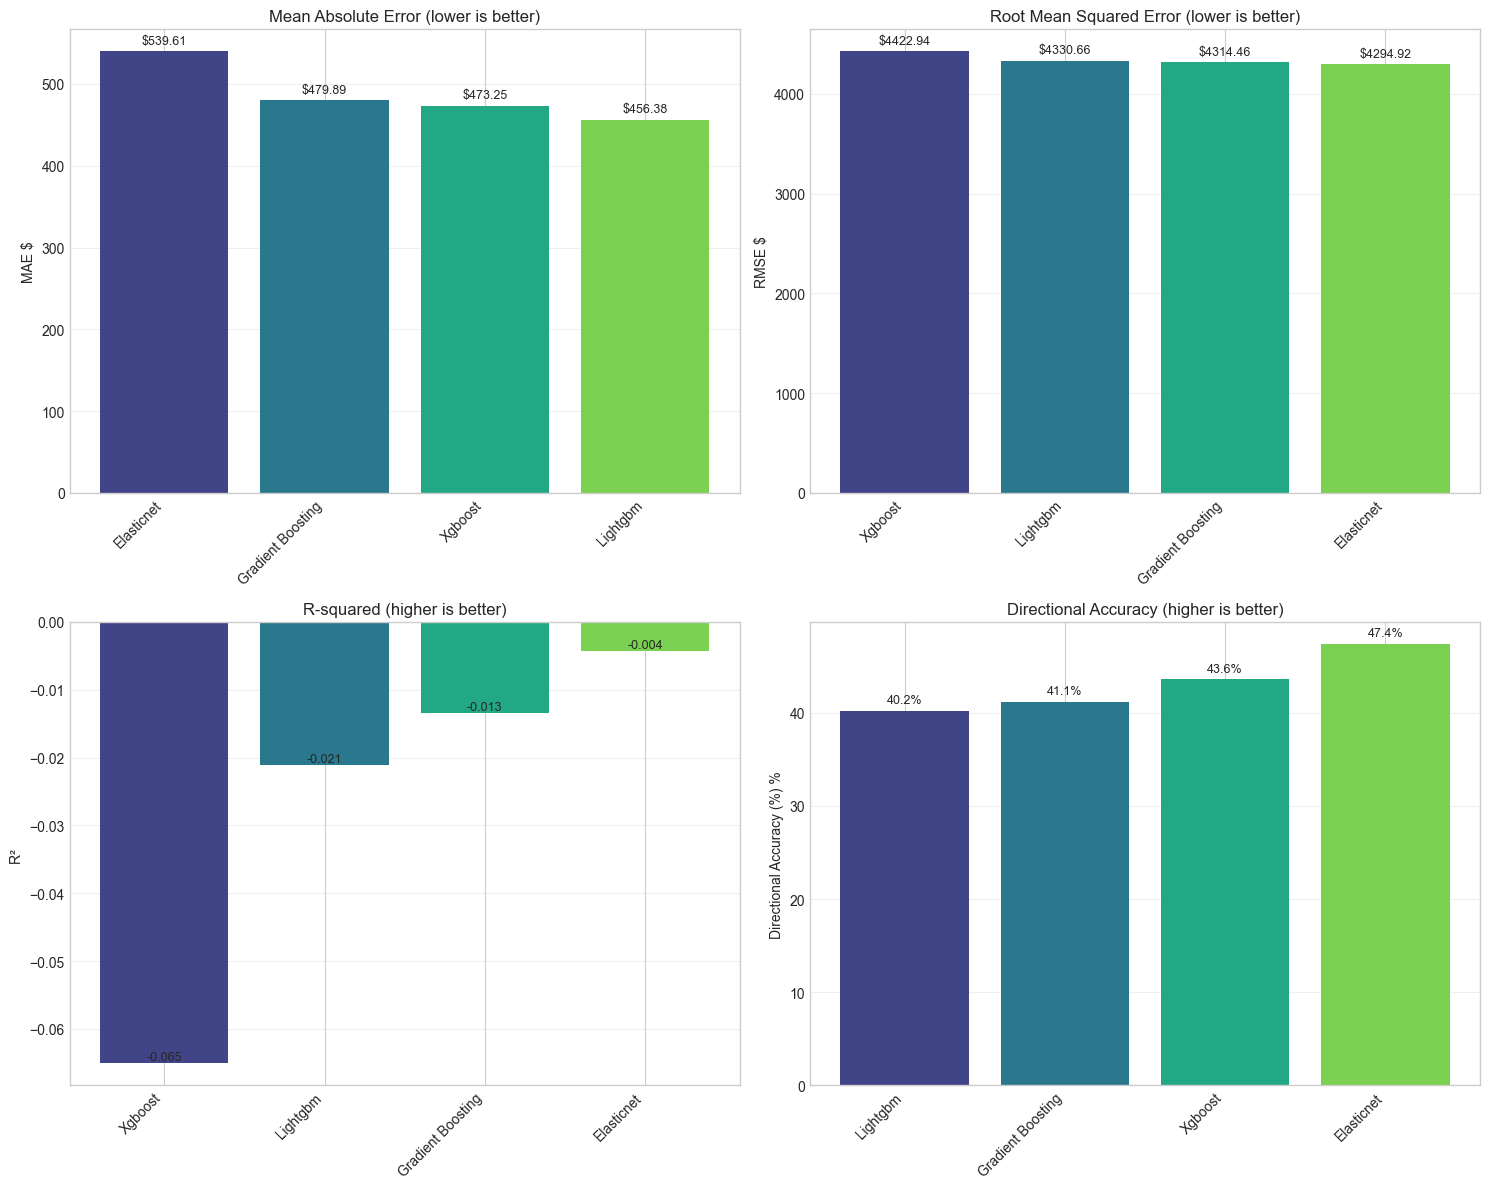

In [11]:
# Create comparison visualizations
plt.figure(figsize=(15, 12))

# Common metrics to visualize
metrics_to_plot = [
    ('MAE', 'Mean Absolute Error (lower is better)', '$'),
    ('RMSE', 'Root Mean Squared Error (lower is better)', '$'),
    ('R²', 'R-squared (higher is better)', ''),
    ('Directional Accuracy (%)', 'Directional Accuracy (higher is better)', '%')
]

# Create subplots for each metric
for i, (metric, title, unit) in enumerate(metrics_to_plot):
    plt.subplot(2, 2, i+1)
    
    # Sort for better visualization
    if metric in ['R²', 'Directional Accuracy (%)']:
        # For these metrics, higher is better
        sorted_idx = metrics_df[metric].argsort()
    else:
        # For these metrics, lower is better
        # Use the negative of values for argsort() to get descending order
        sorted_idx = (-metrics_df[metric]).argsort()
    
    # Create bar chart
    bars = plt.bar(
        metrics_df.iloc[sorted_idx]['Model'], 
        metrics_df.iloc[sorted_idx][metric],
        color=sns.color_palette('viridis', len(metrics_df))
    )
    
    # Add value labels on top of bars
    for bar in bars:
        height = bar.get_height()
        if metric in ['MAE', 'RMSE', 'Median AE']:
            label = f"${height:.2f}"
        elif metric in ['MAPE (%)', 'Directional Accuracy (%)']:
            label = f"{height:.1f}%"
        else:
            label = f"{height:.3f}"
            
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.01 * plt.ylim()[1],
            label,
            ha='center',
            va='bottom',
            rotation=0,
            fontsize=9
        )
    
    plt.title(title)
    plt.ylabel(f"{metric} {unit}")
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

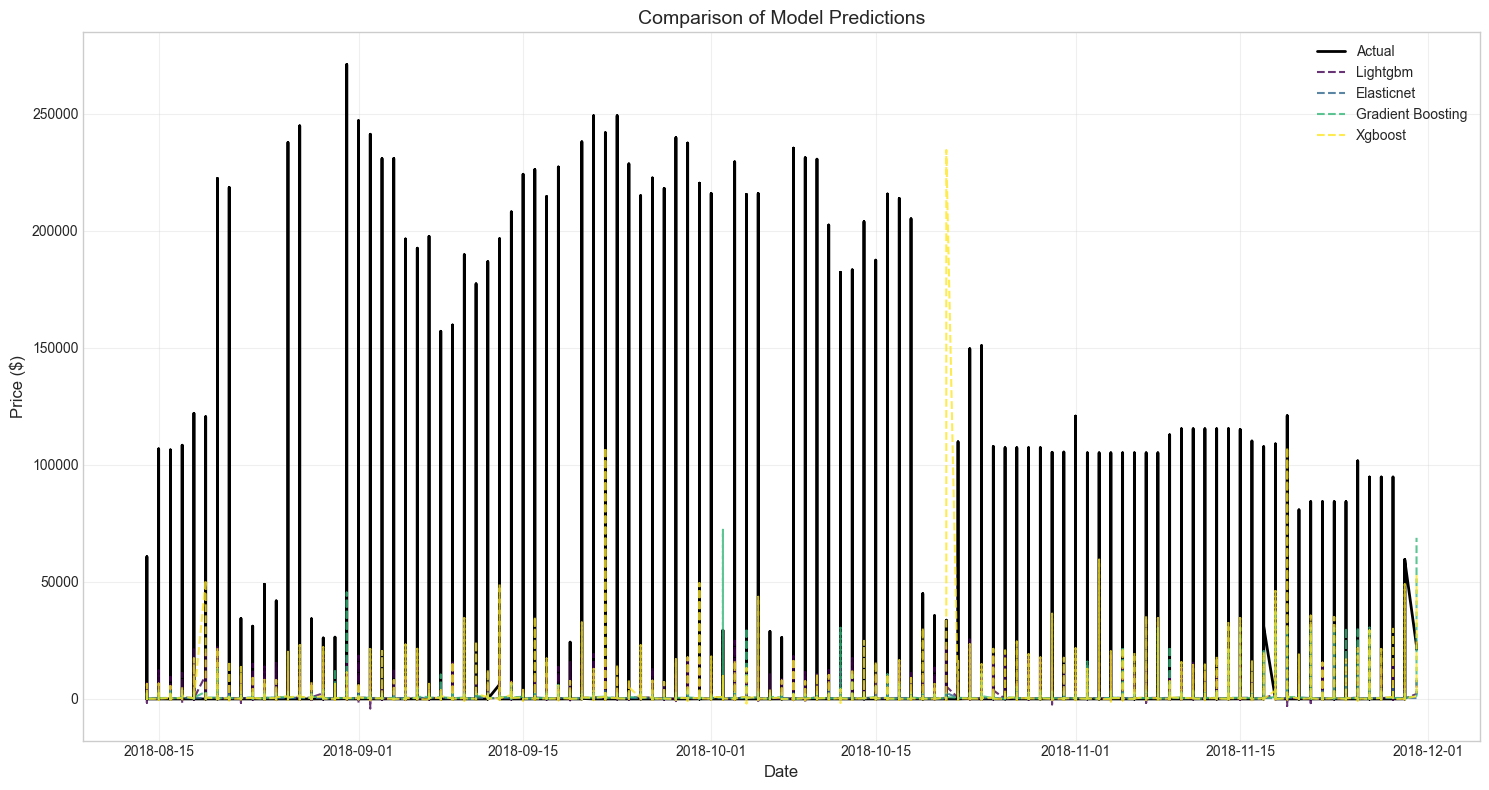

In [12]:
# Visualize predictions from all models
plt.figure(figsize=(15, 8))

# Plot actual values
plt.plot(dates_test, y_test, 'k-', linewidth=2, label='Actual')

# Plot predictions for each model with different colors
colors = plt.cm.viridis(np.linspace(0, 1, len(models)))
for i, (name, preds) in enumerate(predictions.items()):
    plt.plot(
        dates_test,
        preds,
        linestyle='--',
        linewidth=1.5,
        color=colors[i],
        alpha=0.8,
        label=f"{name.replace('_', ' ').title()}"
    )

plt.title('Comparison of Model Predictions', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price ($)', fontsize=12)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

/var/folders/_k/ld7_h48122gctk13bctqqkk40000gn/T/ipykernel_18393/139681794.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(error_data, labels=labels, vert=False)


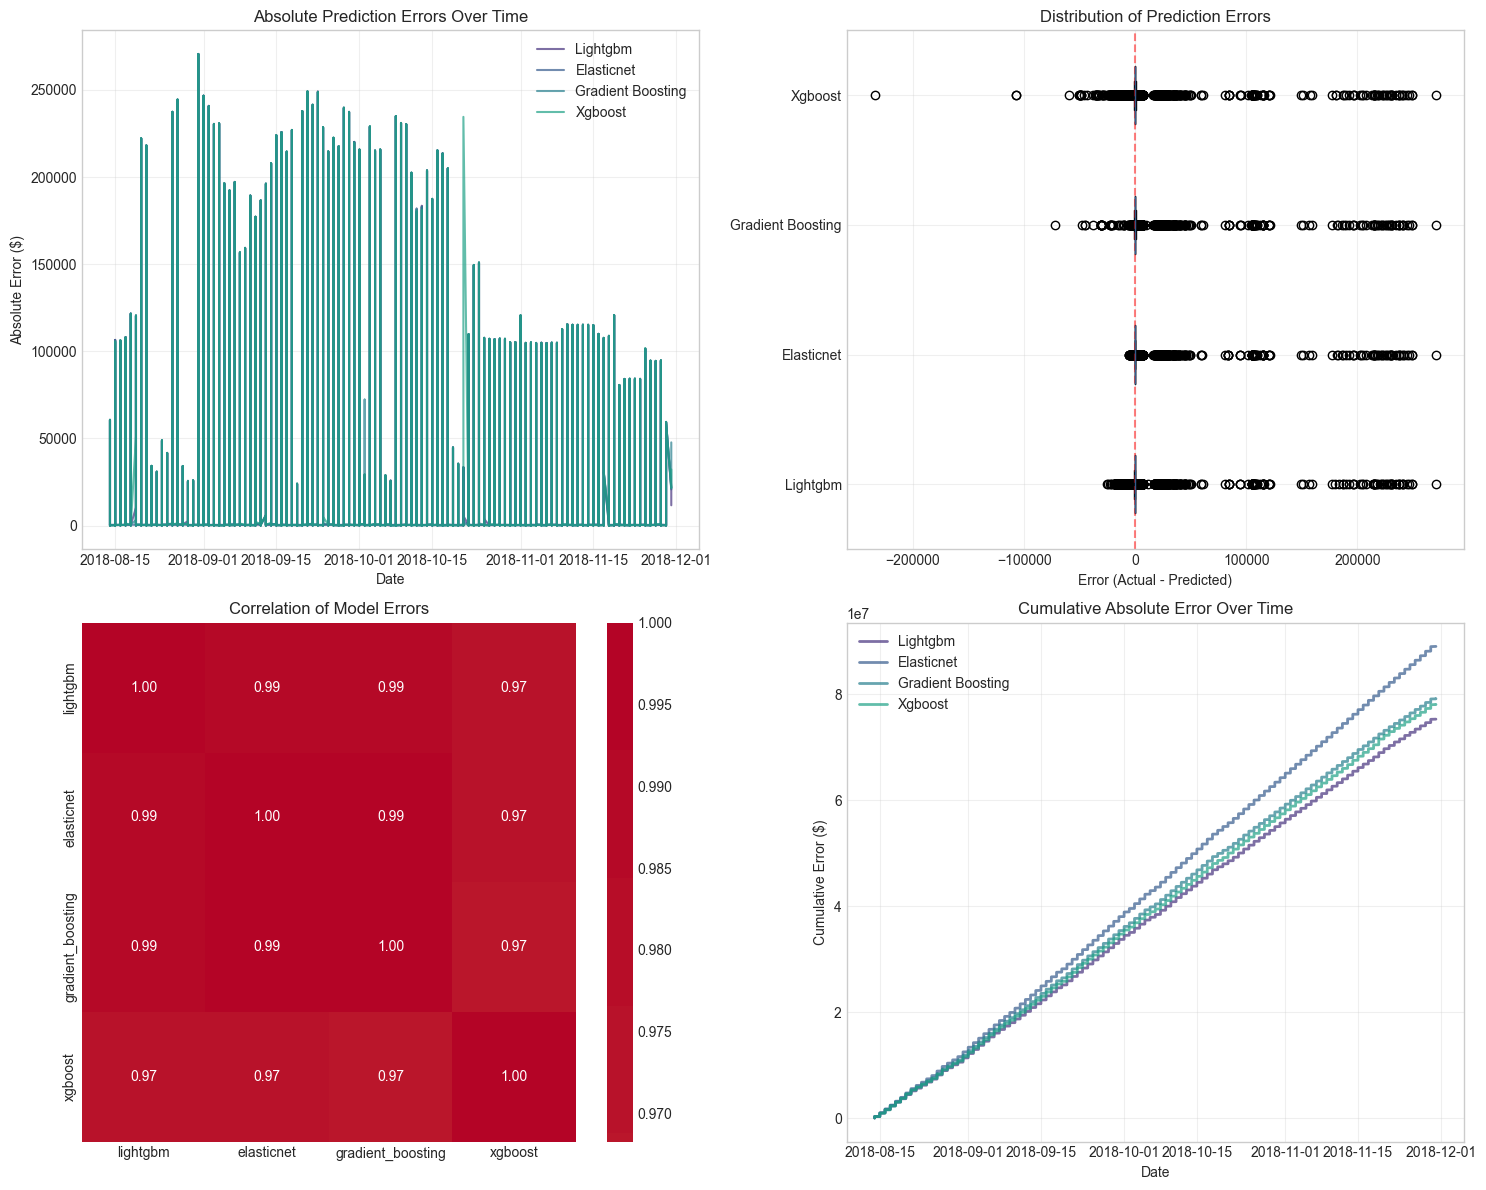

In [13]:
# Create a more detailed comparison of prediction errors
plt.figure(figsize=(15, 12))

# Plot 1: Absolute errors for each model
plt.subplot(2, 2, 1)
for name, preds in predictions.items():
    plt.plot(
        dates_test, 
        np.abs(y_test - preds), 
        alpha=0.7, 
        label=f"{name.replace('_', ' ').title()}"
    )
plt.title('Absolute Prediction Errors Over Time')
plt.xlabel('Date')
plt.ylabel('Absolute Error ($)')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Boxplot of errors
plt.subplot(2, 2, 2)
error_data = []
labels = []
for name, preds in predictions.items():
    error_data.append(y_test - preds)
    labels.append(name.replace('_', ' ').title())
plt.boxplot(error_data, labels=labels, vert=False)
plt.title('Distribution of Prediction Errors')
plt.xlabel('Error (Actual - Predicted)')
plt.axvline(x=0, color='r', linestyle='--', alpha=0.5)
plt.grid(True, alpha=0.3)

# Plot 3: Heatmap of error correlations
plt.subplot(2, 2, 3)
error_df = pd.DataFrame({name: y_test - preds for name, preds in predictions.items()})
error_corr = error_df.corr()
sns.heatmap(error_corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation of Model Errors')

# Plot 4: Cumulative absolute error
plt.subplot(2, 2, 4)
for name, preds in predictions.items():
    plt.plot(
        dates_test,
        np.cumsum(np.abs(y_test - preds)),
        linewidth=2,
        alpha=0.7,
        label=f"{name.replace('_', ' ').title()}"
    )
plt.title('Cumulative Absolute Error Over Time')
plt.xlabel('Date')
plt.ylabel('Cumulative Error ($)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Select the Best Model

Based on the comprehensive evaluation, we'll select the best model considering multiple criteria.

In [14]:
# Determine the best model for different metrics
best_models = {
    'MAE': metrics_df['MAE'].idxmin(),
    'RMSE': metrics_df['RMSE'].idxmin(),
    'R²': metrics_df['R²'].idxmax(),
    'MAPE (%)': metrics_df['MAPE (%)'].idxmin(),
    'Directional Accuracy (%)': metrics_df['Directional Accuracy (%)'].idxmax(),
    'Explained Variance': metrics_df['Explained Variance'].idxmax(),
    'Median AE': metrics_df['Median AE'].idxmin()
}

print("Best model for each metric:")
for metric, model in best_models.items():
    if metric in ['MAE', 'RMSE', 'Median AE']:
        value = f"${metrics_df.loc[model, metric]:.4f}"
    elif metric in ['MAPE (%)', 'Directional Accuracy (%)']:
        value = f"{metrics_df.loc[model, metric]:.2f}%"
    else:
        value = f"{metrics_df.loc[model, metric]:.4f}"
    
    print(f"  {metric}: {model.replace('_', ' ').title()} ({value})")

# Select the overall best model based on MAE
best_model_name = best_models['MAE']
best_model = models[best_model_name]
best_model_metrics = metrics[best_model_name]

print(f"\nSelected best model: {best_model_name.replace('_', ' ').title()}")
print(f"MAE: ${best_model_metrics['MAE']:.4f}")
print(f"RMSE: ${best_model_metrics['RMSE']:.4f}")
print(f"R²: {best_model_metrics['R²']:.4f}")
print(f"Directional Accuracy: {best_model_metrics['Directional Accuracy (%)']:.2f}%")

# Save the best model name for use in other notebooks
with open('../models/best_model_name.txt', 'w') as f:
    f.write(best_model_name)

print(f"\nBest model name saved to '../models/best_model_name.txt'")

Best model for each metric:
  MAE: Lightgbm ($456.3845)
  RMSE: Elasticnet ($4294.9187)
  R²: Elasticnet (-0.0043)
  MAPE (%): Lightgbm (519262135.63%)
  Directional Accuracy (%): Elasticnet (47.36%)
  Explained Variance: Elasticnet (-0.0007)
  Median AE: Lightgbm ($219.6994)

Selected best model: Lightgbm
MAE: $456.3845
RMSE: $4330.6633
R²: -0.0211
Directional Accuracy: 40.20%

Best model name saved to '../models/best_model_name.txt'


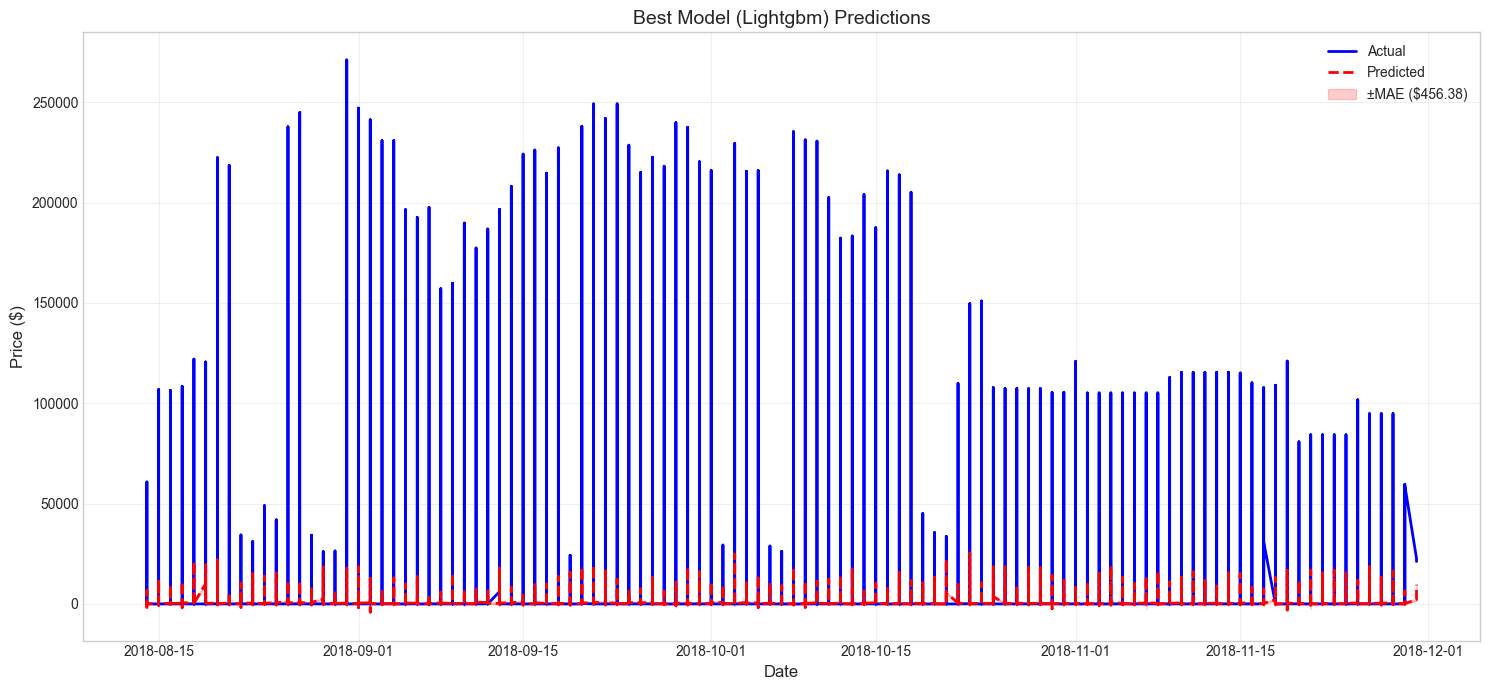

In [15]:
# Visualize the best model's predictions
plt.figure(figsize=(15, 7))

# Plot actual vs. predicted
plt.plot(dates_test, y_test, 'b-', linewidth=2, label='Actual')
plt.plot(dates_test, predictions[best_model_name], 'r--', linewidth=2, label='Predicted')

# Add shaded confidence interval based on MAE
mae = best_model_metrics['MAE']
plt.fill_between(
    dates_test,
    predictions[best_model_name] - mae,
    predictions[best_model_name] + mae,
    color='r',
    alpha=0.2,
    label=f'±MAE (${mae:.2f})'
)

plt.title(f'Best Model ({best_model_name.replace("_", " ").title()}) Predictions', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price ($)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
# Save comprehensive model comparison results
comparison_results = {
    'metrics_df': metrics_df,
    'best_models': best_models,
    'overall_best': best_model_name,
    'date_compared': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')
}

with open('../models/model_comparison_results.pkl', 'wb') as f:
    pickle.dump(comparison_results, f)

print("Comprehensive model comparison results saved to '../models/model_comparison_results.pkl'")

Comprehensive model comparison results saved to '../models/model_comparison_results.pkl'
